In [9]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import Estimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import TwoLocal

In [10]:
mu2 = 1.0

D = np.array([
    [ 5.26786, -3.39048,  0.87619],
    [-3.39048,  5.26786, -3.39048],
    [ 0.87619, -3.39048,  5.26786]
])

Omega = mu2*np.eye(3) + D

In [11]:
## Embed Ω into 4×4
import numpy as np

H_full = np.zeros((4,4))

# physical indices
phys = [0,1,2]

for i in range(3):
    for j in range(3):
        H_full[phys[i], phys[j]] = Omega[i,j]
# Penalize unphysical state |11>
H_full[3,3] = 100.0      

In [12]:
## Convert to Qiskit operator

from qiskit.quantum_info import Operator, SparsePauliOp

op = Operator(H_full)
H = SparsePauliOp.from_operator(op)

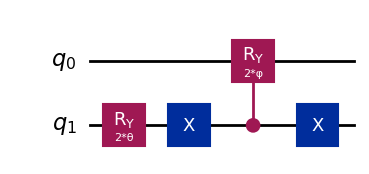

In [13]:
### Quantum circuit

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

theta = Parameter('θ')
phi   = Parameter('φ')
alpha   = Parameter('α')

qc = QuantumCircuit(2)

# Mix |00> <-> |01>
qc.ry(2*theta, 1)

# Controlled rotation only when q1 = 0
qc.x(1)
qc.cry(2*phi, 1, 0)
qc.x(1)
# NEW: extra freedom
#.ry(2*alpha, 0)
qc.draw('mpl')

In [14]:
## Run VQE with Statevector

from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer.primitives import EstimatorV2
from qiskit_algorithms.optimizers import SPSA
optimizer = SPSA(maxiter=300)
#result_exact = VQE(StatevectorEstimator(), qc, COBYLA()).compute_minimum_eigenvalue(H)

estimator = StatevectorEstimator()
#vqe = VQE(
#    estimator,            # shot-based
#    qc,
#    optimizer,
#    initial_point=result_exact.optimal_point
#)

vqe = VQE(estimator, qc, optimizer)
result_sv = vqe.compute_minimum_eigenvalue(H)

print(result_sv.eigenvalue)

1.891227857710268


In [15]:
## Compare with Exact
print(np.linalg.eigvalsh(H_full))
print("Exact energy:", np.min(np.linalg.eigvalsh(H_full)))

[  1.89111996   5.39167     11.52079004 100.        ]
Exact energy: 1.891119957153255


In [16]:
# ================================
# Imports
# ================================

import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

from qiskit_aer.primitives import EstimatorV2
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SPSA

from qiskit.circuit.library import TwoLocal
from qiskit import transpile

# ================================
# YOUR ANSATZ (qc)
# ================================

ansatz = TwoLocal(
    num_qubits=2,
    rotation_blocks="ry",
    entanglement_blocks="cx",
    reps=1,
    entanglement="full"
).decompose()
ansatz = transpile(ansatz)
#theta = Parameter('θ')
#phi   = Parameter('φ')
#alpha = Parameter('α')

#qc = QuantumCircuit(2)

#qc.ry(2*theta, 1)

#qc.x(1)
##qc.x(1)

# NEW: extra freedom
#qc.ry(2*alpha, 0)
#θ1 = Parameter("θ1")
#θ2 = Parameter("θ2")
#φ1 = Parameter("φ1")
#φ2 = Parameter("φ2")

#qc = QuantumCircuit(2)

# Step 1 — distribute amplitude between |00> and |01>
#qc.ry(2*θ1, 1)

# Step 2 — move amplitude from |00> to |10>
#qc.x(1)
#qc.cry(2*θ2, 1, 0)
#qc.x(1)

# Step 3 — relative phase control
#qc.rz(φ1, 1)
#qc.rz(φ2, 0)

# ================================
# INITIAL POINT (CRITICAL)
# ================================

# BEST OPTION: use noiseless VQE result
# initial_point = result_sv.optimal_point

# If not available, use small values
initial_point = np.array([0.1, 0.1, 0.1, 0.1])


# ================================
# SHOT-BASED ESTIMATOR (Aer V2)
# ================================

estimator = EstimatorV2(
    options={
        "run_options": {
            "shots": 16384,   # high for stability
            "seed": 42        # reproducible
        }
    }
)


# ================================
# OPTIMIZER (noise-robust)
# ================================

optimizer = SPSA(
    maxiter=500,
    learning_rate=0.02,
    perturbation=0.05
)


# ================================
# VQE
# ================================
#initial_point = result_sv.optimal_point
vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    initial_point=initial_point
)


# ================================
# RUN VQE
# ================================

result = vqe.compute_minimum_eigenvalue(H)

print("Shot-based energy:", result.eigenvalue.real)
print("Optimal parameters:", result.optimal_point)

Shot-based energy: 1.925407269790476
Optimal parameters: [ 1.87236107 -2.25764151  3.64904869  1.89456654]
